In [2]:
from google.colab import drive
import os, shutil

# Try to unmount in case it's half-mounted
try:
    drive.flush_and_unmount()
except Exception as e:
    print("Unmount info:", e)

# Ensure clean local mountpoint
if os.path.exists("/content/drive"):
    try:
        # Only remove if it's NOT a mount
        if not os.path.ismount("/content/drive"):
            shutil.rmtree("/content/drive")
    except Exception as e:
        print("Cleanup info:", e)
os.makedirs("/content/drive", exist_ok=True)

# Mount fresh
drive.mount("/content/drive", force_remount=True)

# Then set ROOT
ROOT = "/content/drive/MyDrive/Dissertation/Dataset"

%pip -q install imbalanced-learn

from imblearn.over_sampling import SMOTE


Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [3]:
import json
from pathlib import Path

ROOT = "/content/drive/MyDrive/Dissertation/Dataset"
METRICS_DIR = Path(ROOT) / "data" / "metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_PATH = METRICS_DIR / "subject_metrics.json"

def load_metrics_store():
    if METRICS_PATH.exists():
        with open(METRICS_PATH, "r") as f:
            return json.load(f)
    return {}

def save_metrics_store(store: dict):
    with open(METRICS_PATH, "w") as f:
        json.dump(store, f, indent=2)



In [4]:
from pathlib import Path
import numpy as np

ROOT     = "/content/drive/MyDrive/Dissertation/Dataset"
FEATURES = Path(ROOT) / "data" / "features"

def load_subject_flat(subj: str):
    npz_path = FEATURES / f"{subj}_X7_60s_256Hz_final.npz"
    d = np.load(npz_path, allow_pickle=True)
    X = d["X"].reshape(d["X"].shape[0], -1).astype(np.float32)  # (40, 224)
    y = d["y"].astype(int)
    return X, y

# Use first 10 subjects for tuning (adjust if some are missing)
TUNE_SUBJECTS = [f"s{i:02d}" for i in range(1, 11)]

Xs, ys = [], []
for subj in TUNE_SUBJECTS:
    try:
        X_s, y_s = load_subject_flat(subj)
        Xs.append(X_s)
        ys.append(y_s)
        print(f"Loaded {subj}: {X_s.shape}, classes={np.unique(y_s)}")
    except FileNotFoundError:
        print(f"[WARN] Missing features for {subj}, skipping.")

if len(Xs) == 0:
    raise RuntimeError("No subjects loaded for tuning; check paths.")

X_tune = np.vstack(Xs)
y_tune = np.concatenate(ys)

print("Tuning dataset:", X_tune.shape, y_tune.shape, "classes:", np.unique(y_tune))


Loaded s01: (40, 224), classes=[0 1]
Loaded s02: (40, 224), classes=[0 1]
Loaded s03: (40, 224), classes=[0 1]
Loaded s04: (40, 224), classes=[0 1]
Loaded s05: (40, 224), classes=[0 1]
Loaded s06: (40, 224), classes=[0 1]
Loaded s07: (40, 224), classes=[0 1]
Loaded s08: (40, 224), classes=[0 1]
Loaded s09: (40, 224), classes=[0 1]
Loaded s10: (40, 224), classes=[0 1]
Tuning dataset: (400, 224) (400,) classes: [0 1]


In [5]:
# Colab only: install XGBoost if missing
try:
    import xgboost  # noqa
except Exception:
    !pip -q install xgboost

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

try:
    from xgboost import XGBClassifier
    HAVE_XGB = True
except Exception:
    HAVE_XGB = False

SEED = 42

In [6]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 1) Logistic Regression
def tune_logreg_global(X, y, seed=SEED):
    pipe = Pipeline([
        ("sc", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced",
            solver="lbfgs",
            max_iter=3000,
            random_state=seed,
        ))
    ])

    param_grid = {
        "clf__C": [0.01, 0.1, 1.0, 10.0],
    }

    cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv_inner,
        n_jobs=-1,
        refit=True,
        verbose=1,
    )
    gs.fit(X, y)
    print("Best LogReg params:", gs.best_params_)
    print("Best LogReg macro-F1:", gs.best_score_)
    return gs.best_params_


# 2) Linear SVM
def tune_linearsvm_global(X, y, seed=SEED):
    pipe = Pipeline([
        ("sc", StandardScaler()),
        ("clf", LinearSVC(
            class_weight="balanced",
            random_state=seed,
        ))
    ])

    param_grid = {
        "clf__C": [0.01, 0.1, 1.0, 10.0],
    }

    cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv_inner,
        n_jobs=-1,
        refit=True,
        verbose=1,
    )
    gs.fit(X, y)
    print("Best LinearSVM params:", gs.best_params_)
    print("Best LinearSVM macro-F1:", gs.best_score_)
    return gs.best_params_


# 3) RBF SVM – extend a bit beyond what you had
def tune_svm_rbf_global(X, y, seed=SEED):
    pipe = Pipeline([
        ("sc", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=False,
            random_state=seed,
        ))
    ])

    param_grid = {
        "clf__C":     [0.1, 1.0, 10.0, 50.0],
        "clf__gamma": ["scale", 0.01, 0.05, 0.1],
    }

    cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv_inner,
        n_jobs=-1,
        refit=True,
        verbose=1,
    )
    gs.fit(X, y)
    print("Best SVM_RBF params:", gs.best_params_)
    print("Best SVM_RBF macro-F1:", gs.best_score_)
    return gs.best_params_


# 4) Random Forest
def tune_rf_global(X, y, seed=SEED):
    rf = RandomForestClassifier(
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=seed,
    )

    param_grid = {
        "n_estimators": [200, 400, 800],
        "max_depth":    [None, 5, 10],
        "min_samples_leaf": [1, 2],
    }

    cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    gs = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv_inner,
        n_jobs=-1,
        refit=True,
        verbose=1,
    )
    gs.fit(X, y)
    print("Best RF params:", gs.best_params_)
    print("Best RF macro-F1:", gs.best_score_)
    return gs.best_params_


# 5) Gradient Boosting
def tune_gb_global(X, y, seed=SEED):
    gb = GradientBoostingClassifier(
        random_state=seed,
    )

    param_grid = {
        "n_estimators":  [200, 300, 400],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth":     [2, 3],
    }

    cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    gs = GridSearchCV(
        estimator=gb,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv_inner,
        n_jobs=-1,
        refit=True,
        verbose=1,
    )
    gs.fit(X, y)
    print("Best GradBoost params:", gs.best_params_)
    print("Best GradBoost macro-F1:", gs.best_score_)
    return gs.best_params_


# 6) XGBoost – extend a bit (still small)
def tune_xgb_global(X, y, seed=SEED):
    if not HAVE_XGB:
        print("XGBoost not available, skipping.")
        return None

    pos = (y == 1).sum()
    neg = (y != 1).sum()
    spw = (neg / max(pos, 1))

    base = XGBClassifier(
        objective="binary:logistic",
        scale_pos_weight=spw,
        n_estimators=400,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        n_jobs=-1,
        random_state=seed,
        tree_method="hist",
    )

    param_grid = {
        "max_depth":     [3, 4, 5],
        "learning_rate": [0.03, 0.05, 0.1],
        "subsample":     [0.7, 1.0],
    }

    cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    gs = GridSearchCV(
        estimator=base,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv_inner,
        n_jobs=-1,
        refit=True,
        verbose=1,
    )
    gs.fit(X, y)
    print("Best XGB params:", gs.best_params_)
    print("Best XGB macro-F1:", gs.best_score_)
    return gs.best_params_


In [7]:
BEST_PARAMS = {}

BEST_PARAMS["LogReg"]     = tune_logreg_global(X_tune, y_tune, seed=SEED)
BEST_PARAMS["LinearSVM"]  = tune_linearsvm_global(X_tune, y_tune, seed=SEED)
BEST_PARAMS["SVM_RBF"]    = tune_svm_rbf_global(X_tune, y_tune, seed=SEED)
BEST_PARAMS["RandomForest"] = tune_rf_global(X_tune, y_tune, seed=SEED)
BEST_PARAMS["GradBoost"]  = tune_gb_global(X_tune, y_tune, seed=SEED)
BEST_PARAMS["XGBoost"]    = tune_xgb_global(X_tune, y_tune, seed=SEED)

print("\n=== BEST PARAMS SUMMARY ===")
for k, v in BEST_PARAMS.items():
    print(k, ":", v)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best LogReg params: {'clf__C': 0.01}
Best LogReg macro-F1: 0.5719830800869676
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best LinearSVM params: {'clf__C': 0.01}
Best LinearSVM macro-F1: 0.553643151370643
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best SVM_RBF params: {'clf__C': 1.0, 'clf__gamma': 'scale'}
Best SVM_RBF macro-F1: 0.5830013615704827
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best RF params: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 800}
Best RF macro-F1: 0.529717237158682
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best GradBoost params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
Best GradBoost macro-F1: 0.502050105456176
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best XGB params: {'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.7}
Best XGB macro-F1: 0.49698785822618863

=== BEST PARAMS S

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

def build_models(y, seed=SEED):
    """Return dict of leakage-proof sklearn Pipelines per model name."""
    n_classes = len(np.unique(y))
    is_binary = (n_classes == 2)

    models = {}

    # 1) Logistic Regression – tuned C = 0.01
    models["LogReg"] = Pipeline([
        ("sc", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced",
            solver="lbfgs",
            max_iter=3000,
            C=0.01,              # tuned
            random_state=seed))
    ])

    # 2) Linear SVM – tuned C = 0.01
    models["LinearSVM"] = Pipeline([
        ("sc", StandardScaler()),
        ("clf", LinearSVC(
            class_weight="balanced",
            C=0.01,              # tuned
            random_state=seed))
    ])

    # 3) RBF SVM – tuned C=1.0, gamma='scale'
    models["SVM_RBF"] = Pipeline([
        ("sc", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            C=1.0,               # tuned
            gamma="scale",       # tuned
            class_weight="balanced",
            probability=False,
            random_state=seed))
    ])

    # 4) Random Forest – tuned n_estimators, max_depth, min_samples_leaf
    models["RandomForest"] = RandomForestClassifier(
        n_estimators=800,        # tuned
        max_depth=10,            # tuned
        min_samples_leaf=2,      # tuned
        min_samples_split=2,
        class_weight=("balanced_subsample" if is_binary else None),
        n_jobs=-1,
        random_state=seed
    )

    # 5) Gradient Boosting – tuned n_estimators, learning_rate, max_depth
    models["GradBoost"] = GradientBoostingClassifier(
        n_estimators=300,        # tuned
        learning_rate=0.05,      # tuned
        max_depth=3,             # tuned
        random_state=seed
    )

    # 6) XGBoost – tuned max_depth, learning_rate, subsample
    if HAVE_XGB:
        params = dict(
            n_estimators=400,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            n_jobs=-1,
            random_state=seed,
            tree_method="hist",
        )
        if is_binary:
            pos = (y == 1).sum()
            neg = (y != 1).sum()
            spw = (neg / max(pos, 1))
            models["XGBoost"] = XGBClassifier(
                objective="binary:logistic",
                scale_pos_weight=spw,
                max_depth=4,         # tuned
                learning_rate=0.05,  # tuned
                subsample=0.7,       # tuned
                **params
            )
        else:
            models["XGBoost"] = XGBClassifier(
                objective="multi:softprob",
                num_class=n_classes,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.7,
                **params
            )

    return models


In [9]:
def cv_evaluate_models(X, y, n_splits=5, seed=SEED):
    """
    X: (n_samples, n_features)
    y: (n_samples,)  -> binary or multiclass
    Returns: summary_df, details_df
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    models = build_models(y, seed=seed)

    rows_summary = []
    rows_detail  = []

    for name, model in models.items():
        accs, f1s = [], []
        for fold, (tr, te) in enumerate(skf.split(X, y), start=1):
            clf = model
            clf.fit(X[tr], y[tr])
            y_hat = clf.predict(X[te])

            acc = accuracy_score(y[te], y_hat)
            f1m = f1_score(y[te], y_hat, average="macro")

            accs.append(acc); f1s.append(f1m)

            # store detail row
            cm = confusion_matrix(y[te], y_hat)
            rows_detail.append({
                "model": name,
                "fold": fold,
                "acc": acc,
                "macro_f1": f1m,
                "confusion_matrix": cm
            })

        rows_summary.append({
            "model": name,
            "acc_mean":  np.mean(accs),
            "acc_std":   np.std(accs),
            "f1_mean":   np.mean(f1s),
            "f1_std":    np.std(f1s),
            "n_splits":  n_splits
        })

    summary_df = pd.DataFrame(rows_summary).sort_values("f1_mean", ascending=False)
    detail_df  = pd.DataFrame(rows_detail)
    return summary_df, detail_df


In [10]:
def cv_evaluate_models_with_smote(
    X, y, n_splits=5, seed=SEED,
    smote_k_neighbors=5,
    smote_strategy="auto"
):
    """
    Same as cv_evaluate_models, but uses SMOTE (a synthesizer) on the TRAIN
    folds only to create synthetic minority samples in feature space.

    X: (n_samples, n_features)
    y: (n_samples,)
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    models = build_models(y, seed=seed)

    smote = SMOTE(
        sampling_strategy=smote_strategy,   # "auto" -> fully balance classes
        k_neighbors=smote_k_neighbors,
        random_state=seed
    )

    rows_summary = []
    rows_detail  = []

    for name, model in models.items():
        accs, f1s = [], []

        for fold, (tr, te) in enumerate(skf.split(X, y), start=1):
            X_tr, y_tr = X[tr], y[tr]
            X_te, y_te = X[te], y[te]

            # ===== SYNTHESIZER: SMOTE on TRAIN only =====
            try:
                X_tr_bal, y_tr_bal = smote.fit_resample(X_tr, y_tr)
            except ValueError as e:
                # Happens if minority count < k_neighbors+1 in this fold
                # Fallback: skip SMOTE for this fold
                print(f"[WARN] SMOTE failed on fold {fold} for model {name}: {e}")
                X_tr_bal, y_tr_bal = X_tr, y_tr
            # =============================================

            clf = model
            clf.fit(X_tr_bal, y_tr_bal)
            y_hat = clf.predict(X_te)

            acc = accuracy_score(y_te, y_hat)
            f1m = f1_score(y_te, y_hat, average="macro")

            accs.append(acc)
            f1s.append(f1m)

            cm = confusion_matrix(y_te, y_hat)
            rows_detail.append({
                "model": name,
                "fold": fold,
                "acc": acc,
                "macro_f1": f1m,
                "confusion_matrix": cm
            })

        rows_summary.append({
            "model": name,
            "acc_mean":  np.mean(accs),
            "acc_std":   np.std(accs),
            "f1_mean":   np.mean(f1s),
            "f1_std":    np.std(f1s),
            "n_splits":  n_splits
        })

    summary_df = pd.DataFrame(rows_summary).sort_values("f1_mean", ascending=False)
    detail_df  = pd.DataFrame(rows_detail)
    return summary_df, detail_df


In [11]:
def pack_summary_details(summary_df, detail_df):
    """Convert summary + detail into JSON-serializable dict."""
    # ---- models summary ----
    models_summary = {}
    for _, row in summary_df.iterrows():
        mname = row["model"]
        models_summary[mname] = {
            "acc_mean": float(row["acc_mean"]),
            "acc_std":  float(row["acc_std"]),
            "f1_mean":  float(row["f1_mean"]),
            "f1_std":   float(row["f1_std"]),
            "n_splits": int(row["n_splits"]),
        }

    # ---- fold details ----
    fold_details = []
    for _, row in detail_df.iterrows():
        cm = row["confusion_matrix"]
        if isinstance(cm, np.ndarray):
            cm = cm.tolist()
        fold_details.append({
            "model": row["model"],
            "fold": int(row["fold"]),
            "acc": float(row["acc"]),
            "macro_f1": float(row["macro_f1"]),
            "confusion_matrix": cm,
        })

    # ---- best model ----
    best_row = summary_df.iloc[0]
    best_name = best_row["model"]

    best_row_details = detail_df[detail_df["model"] == best_name].iloc[-1]
    best_cm = best_row_details["confusion_matrix"]
    if isinstance(best_cm, np.ndarray):
        best_cm = best_cm.tolist()

    best_metrics = {
        "model": best_name,
        "acc_mean": float(best_row["acc_mean"]),
        "acc_std": float(best_row["acc_std"]),
        "f1_mean": float(best_row["f1_mean"]),
        "f1_std": float(best_row["f1_std"]),
        "last_fold_confusion_matrix": best_cm,
    }

    return {
        "models": models_summary,
        "best": best_metrics,
        "fold_details": fold_details,
    }


In [ ]:
from pathlib import Path
import numpy as np

ROOT     = "/content/drive/MyDrive/Dissertation/Dataset"
FEATURES = Path(ROOT) / "data" / "features"

store = load_metrics_store()

SUBJECTS = [f"s{i:02d}" for i in range(1, 33)]

for subj in SUBJECTS:
    print("=" * 70)
    print(f"Running CV (plain + SMOTE) for {subj}")

    npz_path = FEATURES / f"{subj}_X7_60s_256Hz_final.npz"
    if not npz_path.exists():
        print(f"[SKIP] Missing features file: {npz_path}")
        continue

    # Load features + labels
    fx = np.load(npz_path, allow_pickle=True)
    X = fx["X"].reshape(fx["X"].shape[0], -1).astype(np.float32)
    y = fx["y"].astype(int)

    classes, counts = np.unique(y, return_counts=True)
    print("y classes:", dict(zip(classes, counts)))

    if len(classes) < 2:
        print(f"[SKIP] Only one class present for {subj}, skipping CV.")
        continue

    # ---- CV: PLAIN ----
    summary_plain, details_plain = cv_evaluate_models(X, y, n_splits=5, seed=SEED)

    # ---- CV: SMOTE ----
    summary_smote, details_smote = cv_evaluate_models_with_smote(X, y, n_splits=5, seed=SEED)

    # ---- Pack both into JSON-ready blocks ----
    plain_block = pack_summary_details(summary_plain, details_plain)
    smote_block = pack_summary_details(summary_smote, details_smote)

    # ---- Store under subject key (replaces that subject’s old metrics) ----
    store[subj] = {
        "subject": subj,
        "plain": plain_block,
        "smote": smote_block,
    }

    print(f"{subj}: best (plain) model -> {plain_block['best']['model']} "
          f"| f1_mean = {plain_block['best']['f1_mean']:.3f}")
    print(f"{subj}: best (SMOTE) model -> {smote_block['best']['model']} "
          f"| f1_mean = {smote_block['best']['f1_mean']:.3f}")

# Save once at the end
save_metrics_store(store)
print("\nAll done. Metrics updated for:", [s for s in SUBJECTS if s in store])
print("JSON path:", METRICS_PATH)


Running CV (plain + SMOTE) for s01
y classes: {np.int64(0): np.int64(22), np.int64(1): np.int64(18)}
s01: best (plain) model -> LogReg | f1_mean = 0.527
s01: best (SMOTE) model -> GradBoost | f1_mean = 0.560
Running CV (plain + SMOTE) for s02
y classes: {np.int64(0): np.int64(20), np.int64(1): np.int64(20)}
s02: best (plain) model -> SVM_RBF | f1_mean = 0.529
s02: best (SMOTE) model -> SVM_RBF | f1_mean = 0.529
Running CV (plain + SMOTE) for s03
y classes: {np.int64(0): np.int64(31), np.int64(1): np.int64(9)}
s03: best (plain) model -> LinearSVM | f1_mean = 0.680
s03: best (SMOTE) model -> LogReg | f1_mean = 0.636
Running CV (plain + SMOTE) for s04
y classes: {np.int64(0): np.int64(29), np.int64(1): np.int64(11)}
s04: best (plain) model -> LinearSVM | f1_mean = 0.556
s04: best (SMOTE) model -> LinearSVM | f1_mean = 0.513
Running CV (plain + SMOTE) for s05
y classes: {np.int64(0): np.int64(18), np.int64(1): np.int64(22)}
s05: best (plain) model -> GradBoost | f1_mean = 0.550
s05: best (

In [ ]:
import pandas as pd
import json

def subject_summary_plain_smote(subj: str):
    store = load_metrics_store()
    if subj not in store:
        raise KeyError(f"No metrics for {subj}")

    entry = store[subj]
    plain_models = entry["plain"]["models"]
    smote_models = entry["smote"]["models"]

    model_names = list(plain_models.keys())
    for m in smote_models.keys():
        if m not in model_names:
            model_names.append(m)

    rows_plain = []
    rows_smote = []

    for mname in model_names:
        p = plain_models.get(mname, None)
        s = smote_models.get(mname, None)

        rows_plain.append({
            "model": mname,
            "acc_mean":  p["acc_mean"] if p is not None else None,
            "acc_std":   p["acc_std"]  if p is not None else None,
            "f1_mean":   p["f1_mean"]  if p is not None else None,
            "f1_std":    p["f1_std"]   if p is not None else None,
            "n_splits":  p["n_splits"] if p is not None else None,
        })

        rows_smote.append({
            "model": mname,
            "acc_mean":  s["acc_mean"] if s is not None else None,
            "acc_std":   s["acc_std"]  if s is not None else None,
            "f1_mean":   s["f1_mean"]  if s is not None else None,
            "f1_std":    s["f1_std"]   if s is not None else None,
            "n_splits":  s["n_splits"] if s is not None else None,
        })

    df_plain = pd.DataFrame(rows_plain).set_index("model")
    df_smote = pd.DataFrame(rows_smote).set_index("model")

    order = df_smote["f1_mean"].sort_values(ascending=False).index
    df_plain = df_plain.loc[order].reset_index()
    df_smote = df_smote.loc[order].reset_index()

    return df_plain, df_smote

def show_subject_summary_two(subj: str):
    df_plain, df_smote = subject_summary_plain_smote(subj)
    print(f"=== PLAIN (no SMOTE) – {subj} ===")
    display(df_plain.round(3))
    print(f"\n=== SMOTE – {subj} ===")
    display(df_smote.round(3))

# Example check:
show_subject_summary_two("s15")


=== PLAIN (no SMOTE) – s15 ===


,model,acc_mean,acc_std,f1_mean,f1_std,n_splits
0,LogReg,0.675,0.203,0.624,0.232,5
1,RandomForest,0.675,0.100,0.608,0.150,5
2,LinearSVM,0.675,0.100,0.644,0.099,5
3,XGBoost,0.725,0.146,0.663,0.205,5
4,SVM_RBF,0.625,0.112,0.573,0.083,5
5,GradBoost,0.500,0.137,0.464,0.150,5



=== SMOTE – s15 ===


,model,acc_mean,acc_std,f1_mean,f1_std,n_splits
0,LogReg,0.725,0.146,0.694,0.157,5
1,RandomForest,0.725,0.094,0.691,0.102,5
2,LinearSVM,0.725,0.050,0.687,0.048,5
3,XGBoost,0.700,0.100,0.634,0.161,5
4,SVM_RBF,0.650,0.094,0.603,0.064,5
5,GradBoost,0.550,0.257,0.513,0.273,5


In [ ]:
import json
import pandas as pd
from pathlib import Path
from IPython.display import display, HTML

ROOT = "/content/drive/MyDrive/Dissertation/Dataset"
METRICS_PATH = Path(ROOT) / "data" / "metrics" / "subject_metrics.json"

with open(METRICS_PATH, "r") as f:
    metrics = json.load(f)

for i in range(1, 33):
    subj = f"s{i:02d}"
    if subj not in metrics:
        print(f"[WARN] {subj} missing in metrics JSON, skipping.")
        continue

    subj_block = metrics[subj]

    # --- Build summary tables from 'models' dict ---
    plain_models = subj_block["plain"]["models"]
    df_plain = (
        pd.DataFrame.from_dict(plain_models, orient="index")
        .reset_index()
        .rename(columns={"index": "model"})
    )

    smote_models = subj_block["smote"]["models"]
    df_smote = (
        pd.DataFrame.from_dict(smote_models, orient="index")
        .reset_index()
        .rename(columns={"index": "model"})
    )

    # Round numeric columns for readability
    for df in (df_plain, df_smote):
        for col in ["acc_mean", "acc_std", "f1_mean", "f1_std"]:
            if col in df.columns:
                df[col] = df[col].astype(float).round(3)

    html = f"""
    <h3>{subj}</h3>
    <div style="display:flex; gap:30px; align-items:flex-start;">
      <div>
        <h4>Plain</h4>
        {df_plain.to_html(index=False)}
      </div>
      <div>
        <h4>SMOTE</h4>
        {df_smote.to_html(index=False)}
      </div>
    </div>
    <hr>
    """
    display(HTML(html))


model,acc_mean,acc_std,f1_mean,f1_std,n_splits
LogReg,0.550,0.100,0.527,0.104,5
SVM_RBF,0.500,0.112,0.475,0.138,5
LinearSVM,0.525,0.255,0.471,0.285,5
GradBoost,0.450,0.100,0.432,0.084,5
XGBoost,0.425,0.127,0.399,0.126,5
RandomForest,0.400,0.122,0.326,0.119,5
model,acc_mean,acc_std,f1_mean,f1_std,n_splits
GradBoost,0.575,0.061,0.560,0.053,5
SVM_RBF,0.500,0.112,0.475,0.138,5
LogReg,0.500,0.079,0.465,0.111,5


model,acc_mean,acc_std,f1_mean,f1_std,n_splits
SVM_RBF,0.550,0.127,0.529,0.128,5
LogReg,0.500,0.177,0.476,0.185,5
GradBoost,0.450,0.061,0.408,0.078,5
LinearSVM,0.425,0.150,0.390,0.146,5
XGBoost,0.400,0.094,0.373,0.098,5
RandomForest,0.400,0.050,0.348,0.072,5
model,acc_mean,acc_std,f1_mean,f1_std,n_splits
SVM_RBF,0.550,0.127,0.529,0.128,5
LogReg,0.500,0.177,0.476,0.185,5
GradBoost,0.450,0.061,0.408,0.078,5


model,acc_mean,acc_std,f1_mean,f1_std,n_splits
LinearSVM,0.750,0.224,0.680,0.258,5
GradBoost,0.800,0.170,0.670,0.250,5
LogReg,0.775,0.166,0.636,0.243,5
SVM_RBF,0.825,0.061,0.595,0.189,5
RandomForest,0.800,0.061,0.509,0.143,5
XGBoost,0.650,0.146,0.450,0.153,5
model,acc_mean,acc_std,f1_mean,f1_std,n_splits
LogReg,0.775,0.166,0.636,0.243,5
LinearSVM,0.750,0.209,0.597,0.280,5
RandomForest,0.825,0.061,0.595,0.189,5


model,acc_mean,acc_std,f1_mean,f1_std,n_splits
LinearSVM,0.625,0.137,0.556,0.171,5
SVM_RBF,0.600,0.094,0.483,0.120,5
RandomForest,0.700,0.100,0.457,0.111,5
GradBoost,0.550,0.187,0.419,0.154,5
LogReg,0.525,0.094,0.404,0.102,5
XGBoost,0.575,0.100,0.389,0.053,5
model,acc_mean,acc_std,f1_mean,f1_std,n_splits
LinearSVM,0.625,0.112,0.513,0.151,5
LogReg,0.575,0.100,0.473,0.130,5
SVM_RBF,0.700,0.100,0.410,0.038,5


model,acc_mean,acc_std,f1_mean,f1_std,n_splits
GradBoost,0.550,0.292,0.550,0.292,5
LinearSVM,0.425,0.100,0.416,0.102,5
LogReg,0.400,0.122,0.387,0.112,5
XGBoost,0.400,0.184,0.386,0.193,5
RandomForest,0.400,0.146,0.369,0.134,5
SVM_RBF,0.300,0.150,0.290,0.155,5
model,acc_mean,acc_std,f1_mean,f1_std,n_splits
LinearSVM,0.475,0.146,0.466,0.144,5
XGBoost,0.425,0.150,0.407,0.158,5
RandomForest,0.425,0.100,0.403,0.086,5


...

model,acc_mean,acc_std,f1_mean,f1_std,n_splits
GradBoost,0.550,0.127,0.526,0.122,5
LinearSVM,0.500,0.112,0.487,0.114,5
SVM_RBF,0.475,0.146,0.471,0.145,5
LogReg,0.400,0.146,0.397,0.144,5
RandomForest,0.450,0.170,0.395,0.161,5
XGBoost,0.375,0.079,0.369,0.079,5
model,acc_mean,acc_std,f1_mean,f1_std,n_splits
GradBoost,0.550,0.127,0.522,0.130,5
LinearSVM,0.500,0.112,0.487,0.114,5
SVM_RBF,0.475,0.146,0.461,0.160,5


model,acc_mean,acc_std,f1_mean,f1_std,n_splits
RandomForest,0.600,0.184,0.574,0.178,5
GradBoost,0.600,0.184,0.568,0.181,5
LinearSVM,0.525,0.184,0.521,0.184,5
SVM_RBF,0.525,0.242,0.504,0.231,5
LogReg,0.475,0.184,0.451,0.199,5
XGBoost,0.425,0.127,0.358,0.142,5
model,acc_mean,acc_std,f1_mean,f1_std,n_splits
SVM_RBF,0.600,0.242,0.578,0.233,5
RandomForest,0.575,0.203,0.547,0.197,5
GradBoost,0.575,0.203,0.547,0.197,5


model,acc_mean,acc_std,f1_mean,f1_std,n_splits
LinearSVM,0.600,0.122,0.587,0.120,5
LogReg,0.575,0.100,0.554,0.114,5
SVM_RBF,0.575,0.100,0.550,0.109,5
GradBoost,0.575,0.127,0.536,0.108,5
RandomForest,0.550,0.061,0.479,0.085,5
XGBoost,0.500,0.112,0.465,0.089,5
model,acc_mean,acc_std,f1_mean,f1_std,n_splits
LogReg,0.625,0.137,0.598,0.150,5
XGBoost,0.575,0.061,0.549,0.045,5
SVM_RBF,0.575,0.127,0.536,0.108,5


model,acc_mean,acc_std,f1_mean,f1_std,n_splits
LinearSVM,0.675,0.100,0.656,0.104,5
GradBoost,0.650,0.122,0.581,0.167,5
LogReg,0.625,0.137,0.556,0.160,5
SVM_RBF,0.575,0.127,0.512,0.147,5
XGBoost,0.575,0.127,0.506,0.141,5
RandomForest,0.600,0.122,0.419,0.131,5
model,acc_mean,acc_std,f1_mean,f1_std,n_splits
LinearSVM,0.700,0.187,0.660,0.227,5
XGBoost,0.600,0.146,0.562,0.137,5
GradBoost,0.625,0.194,0.550,0.221,5


model,acc_mean,acc_std,f1_mean,f1_std,n_splits
LogReg,0.625,0.237,0.606,0.256,5
SVM_RBF,0.600,0.215,0.567,0.231,5
RandomForest,0.575,0.170,0.543,0.192,5
LinearSVM,0.550,0.218,0.540,0.219,5
GradBoost,0.550,0.170,0.539,0.176,5
XGBoost,0.500,0.112,0.469,0.137,5
model,acc_mean,acc_std,f1_mean,f1_std,n_splits
LogReg,0.575,0.203,0.556,0.221,5
RandomForest,0.575,0.170,0.543,0.192,5
LinearSVM,0.525,0.215,0.517,0.216,5


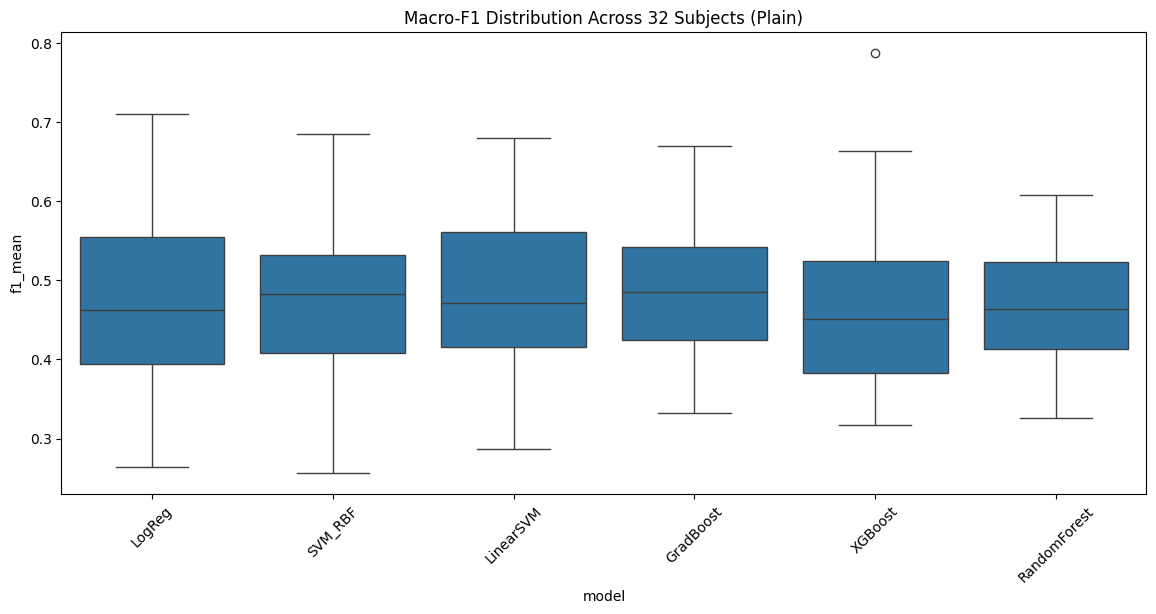

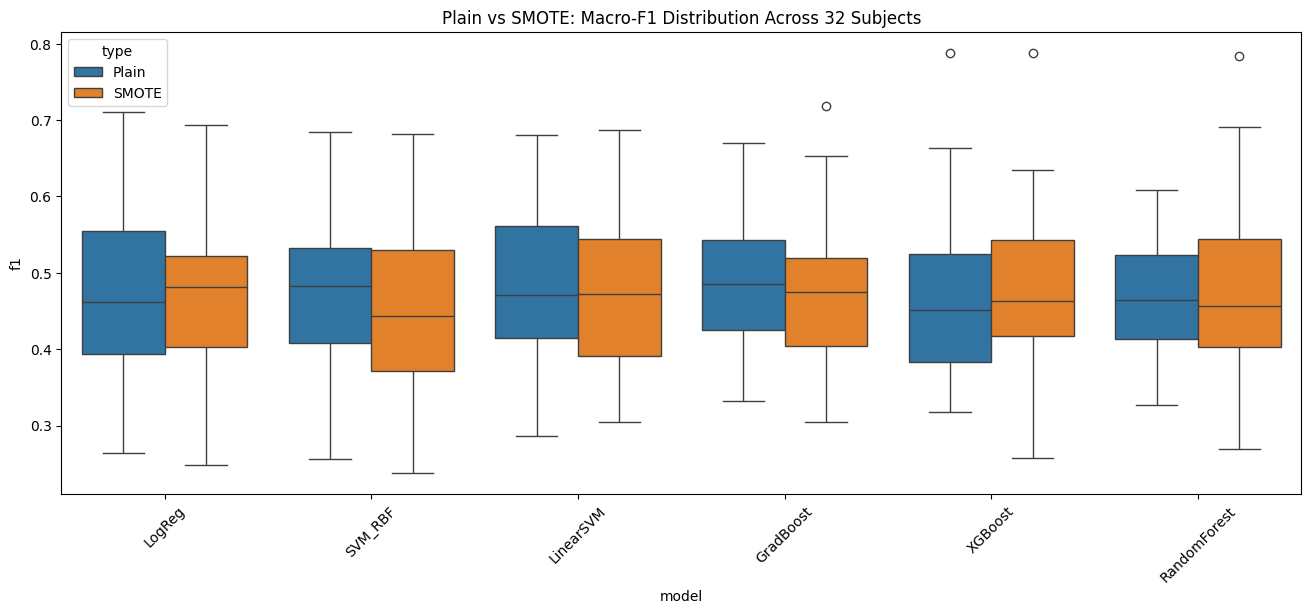

In [ ]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Load metrics
ROOT = "/content/drive/MyDrive/Dissertation/Dataset"
METRICS_PATH = Path(ROOT) / "data" / "metrics" / "subject_metrics.json"

with open(METRICS_PATH, "r") as f:
    metrics = json.load(f)

rows = []
for subj in metrics:
    for model_name, vals in metrics[subj]["plain"]["models"].items():
        rows.append({
            "subject": subj,
            "model": model_name,
            "acc_mean": vals["acc_mean"],
            "f1_mean": vals["f1_mean"],
            "type": "Plain"
        })

df_plain = pd.DataFrame(rows)

plt.figure(figsize=(14,6))
sns.boxplot(data=df_plain, x="model", y="f1_mean")
plt.title("Macro-F1 Distribution Across 32 Subjects (Plain)")
plt.xticks(rotation=45)
plt.show()


rows = []
for subj in metrics:
    for m in metrics[subj]["plain"]["models"]:
        rows.append({
            "subject": subj,
            "model": m,
            "f1": metrics[subj]["plain"]["models"][m]["f1_mean"],
            "type": "Plain"
        })
    for m in metrics[subj]["smote"]["models"]:
        rows.append({
            "subject": subj,
            "model": m,
            "f1": metrics[subj]["smote"]["models"][m]["f1_mean"],
            "type": "SMOTE"
        })

df_compare = pd.DataFrame(rows)

plt.figure(figsize=(16,6))
sns.boxplot(data=df_compare, x="model", y="f1", hue="type")
plt.title("Plain vs SMOTE: Macro-F1 Distribution Across 32 Subjects")
plt.xticks(rotation=45)
plt.show()


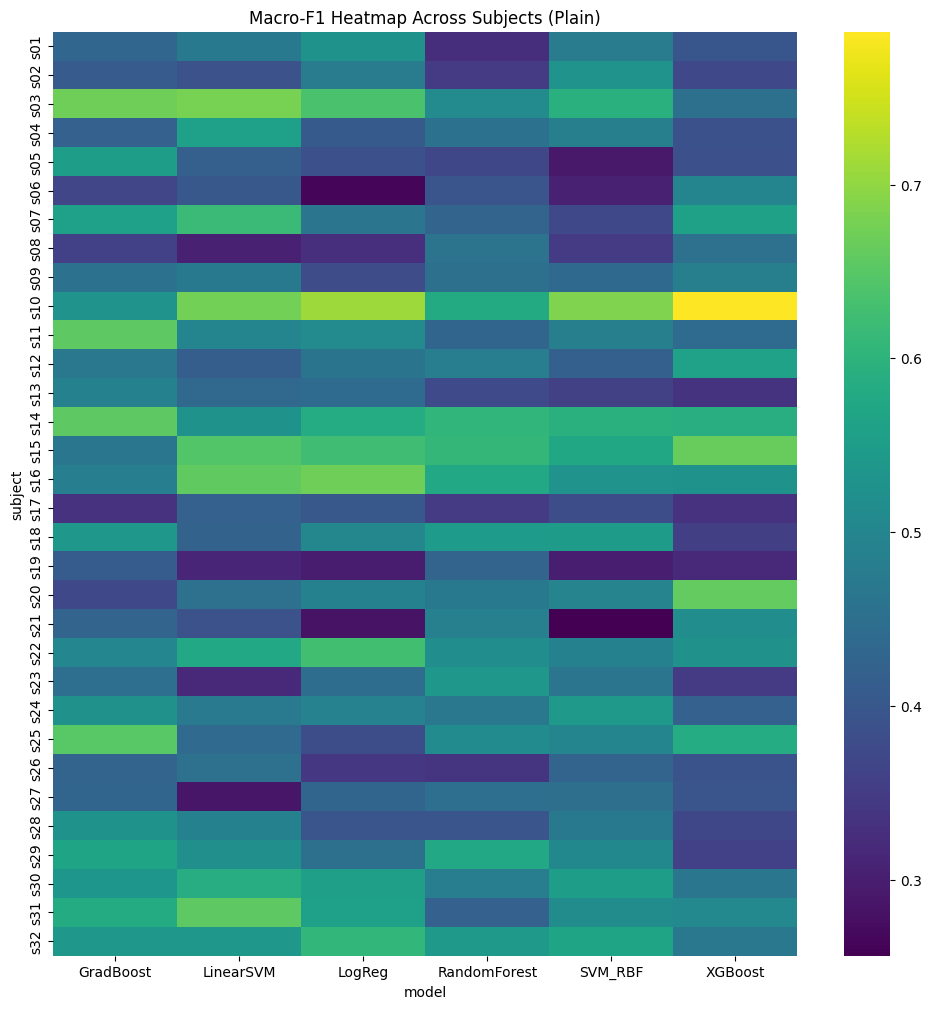

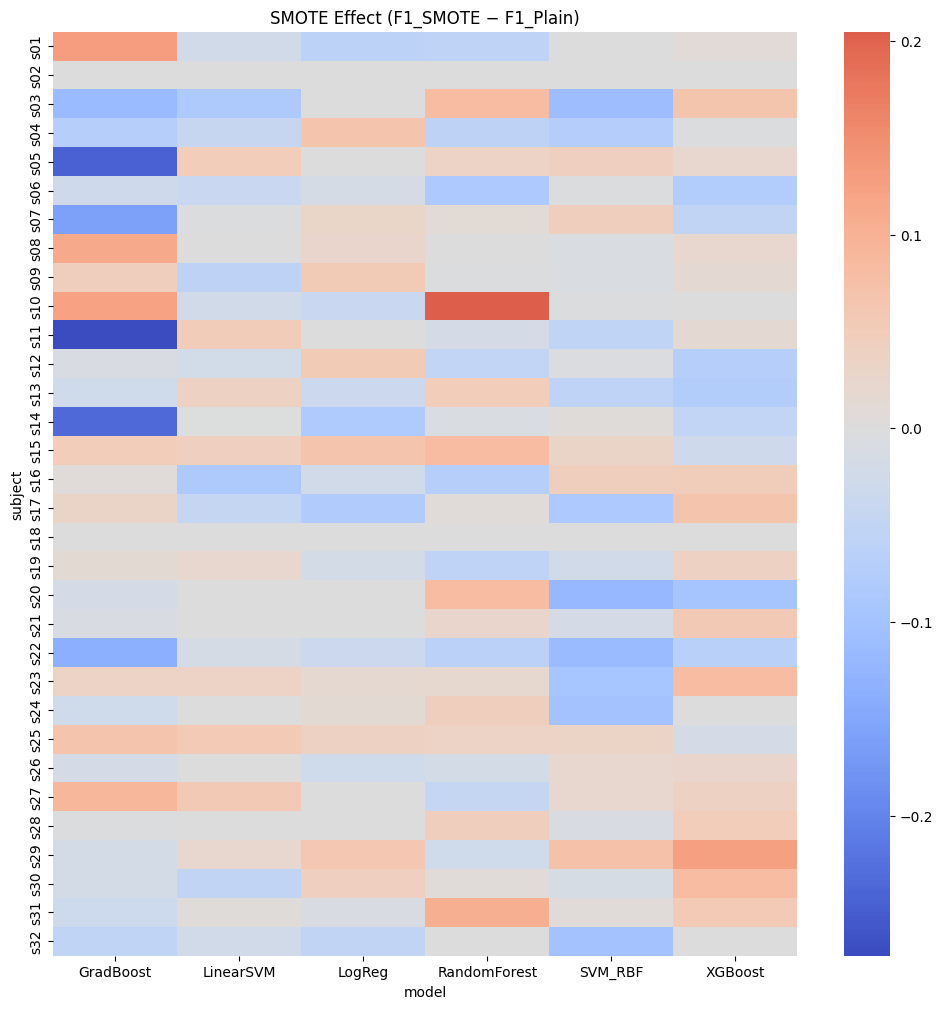

In [ ]:
pivot_df = df_plain.pivot(index="subject", columns="model", values="f1_mean")

plt.figure(figsize=(12,12))
sns.heatmap(pivot_df, annot=False, cmap="viridis")
plt.title("Macro-F1 Heatmap Across Subjects (Plain)")
plt.show()


# Build SMOTE df
rows_sm = []
for subj in metrics:
    for model_name, vals in metrics[subj]["smote"]["models"].items():
        rows_sm.append({
            "subject": subj,
            "model": model_name,
            "f1_mean": vals["f1_mean"],
        })
df_smote = pd.DataFrame(rows_sm)

# Merge
merged = df_plain.merge(df_smote, on=["subject","model"], suffixes=("_plain","_smote"))
merged["diff"] = merged["f1_mean_smote"] - merged["f1_mean_plain"]

pivot_diff = merged.pivot(index="subject", columns="model", values="diff")

plt.figure(figsize=(12,12))
sns.heatmap(pivot_diff, cmap="coolwarm", center=0)
plt.title("SMOTE Effect (F1_SMOTE − F1_Plain)")
plt.show()


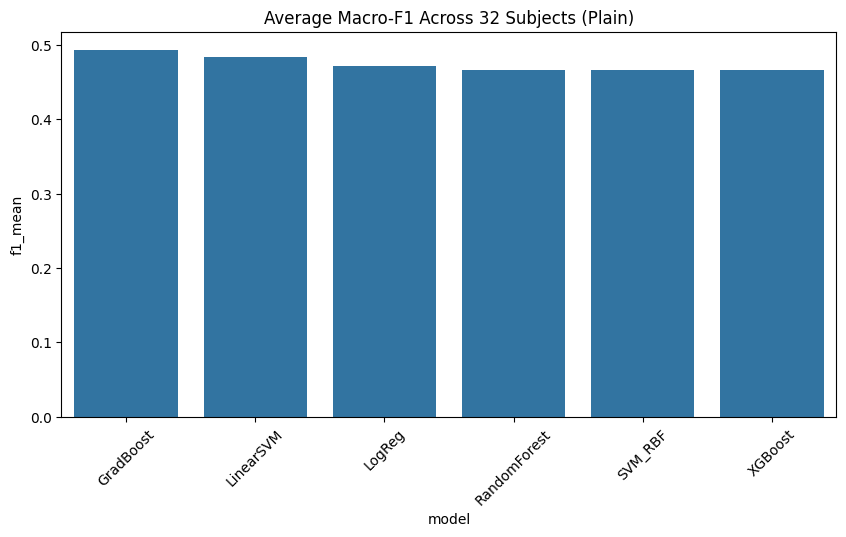

In [ ]:
mean_df = df_plain.groupby("model")["f1_mean"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=mean_df, x="model", y="f1_mean")
plt.title("Average Macro-F1 Across 32 Subjects (Plain)")
plt.xticks(rotation=45)
plt.show()


In [ ]:
import json
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Load metrics
ROOT = "/content/drive/MyDrive/Dissertation/Dataset"
METRICS_PATH = Path(ROOT) / "data" / "metrics" / "subject_metrics.json"

with open(METRICS_PATH, "r") as f:
    metrics = json.load(f)

rows = []
for subj in metrics:
    for model_name, vals in metrics[subj]["plain"]["models"].items():
        rows.append({
            "subject": subj,
            "model": model_name,
            "type": "Plain",
            "acc": vals["acc_mean"],
            "f1": vals["f1_mean"],
        })
    for model_name, vals in metrics[subj]["smote"]["models"].items():
        rows.append({
            "subject": subj,
            "model": model_name,
            "type": "SMOTE",
            "acc": vals["acc_mean"],
            "f1": vals["f1_mean"],
        })

df = pd.DataFrame(rows)
df.head()


,subject,model,type,acc,f1
0,s01,LogReg,Plain,0.550,0.526667
1,s01,SVM_RBF,Plain,0.500,0.475180
2,s01,LinearSVM,Plain,0.525,0.471270
3,s01,GradBoost,Plain,0.450,0.431775
4,s01,XGBoost,Plain,0.425,0.398759


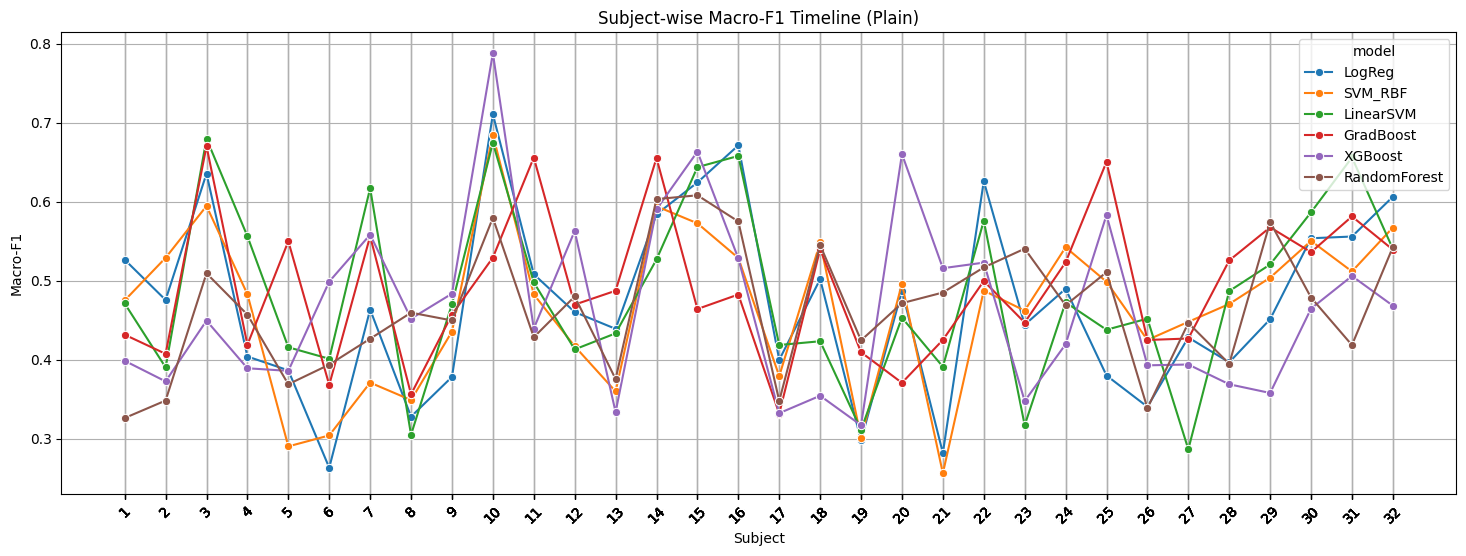

In [ ]:
df_plain = df[df["type"] == "Plain"].copy()

# Sort subjects numerically
df_plain["subj_num"] = df_plain["subject"].str.replace("s", "").astype(int)
df_plain = df_plain.sort_values("subj_num")

plt.figure(figsize=(18,6))
sns.lineplot(
    data=df_plain,
    x="subj_num",
    y="f1",
    hue="model",
    marker="o"
)
plt.xticks(df_plain["subj_num"], rotation=45)
plt.title("Subject-wise Macro-F1 Timeline (Plain)")
plt.xlabel("Subject")
plt.ylabel("Macro-F1")
plt.grid(True)
plt.show()


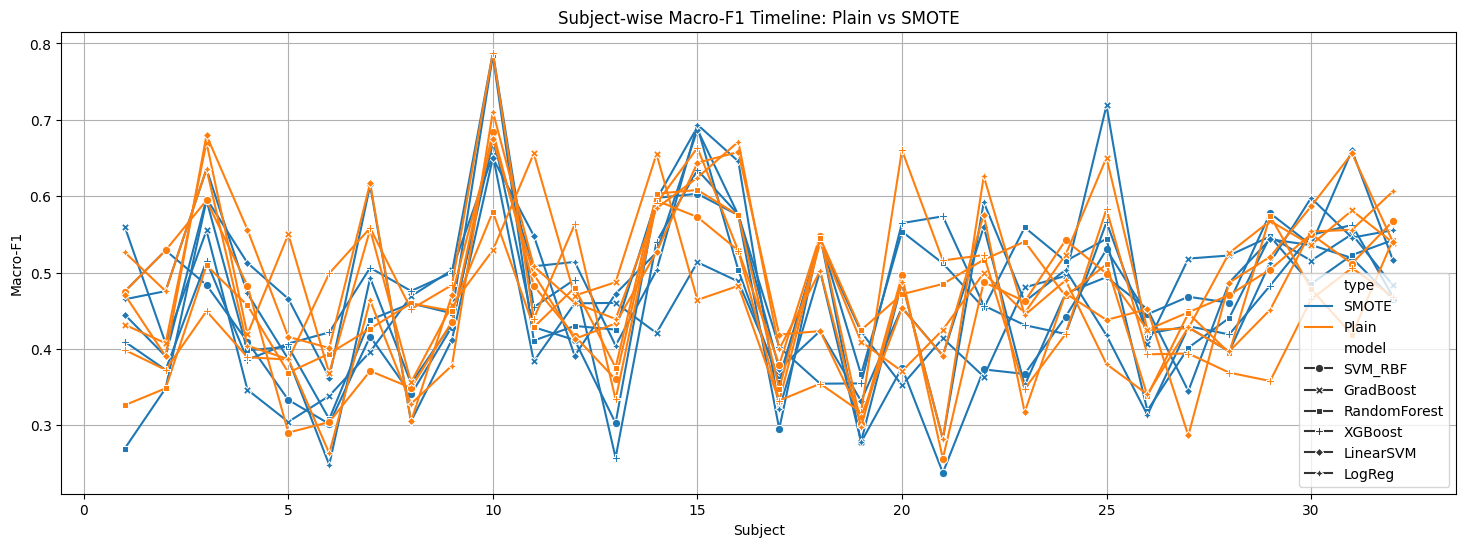

In [ ]:
df_compare = df.copy()
df_compare["subj_num"] = df_compare["subject"].str.replace("s","").astype(int)
df_compare = df_compare.sort_values("subj_num")

plt.figure(figsize=(18,6))
sns.lineplot(
    data=df_compare,
    x="subj_num",
    y="f1",
    hue="type",          # Plain vs SMOTE
    style="model",       # Model as line style
    markers=True,
    dashes=False
)
plt.title("Subject-wise Macro-F1 Timeline: Plain vs SMOTE")
plt.xlabel("Subject")
plt.ylabel("Macro-F1")
plt.grid(True)
plt.show()


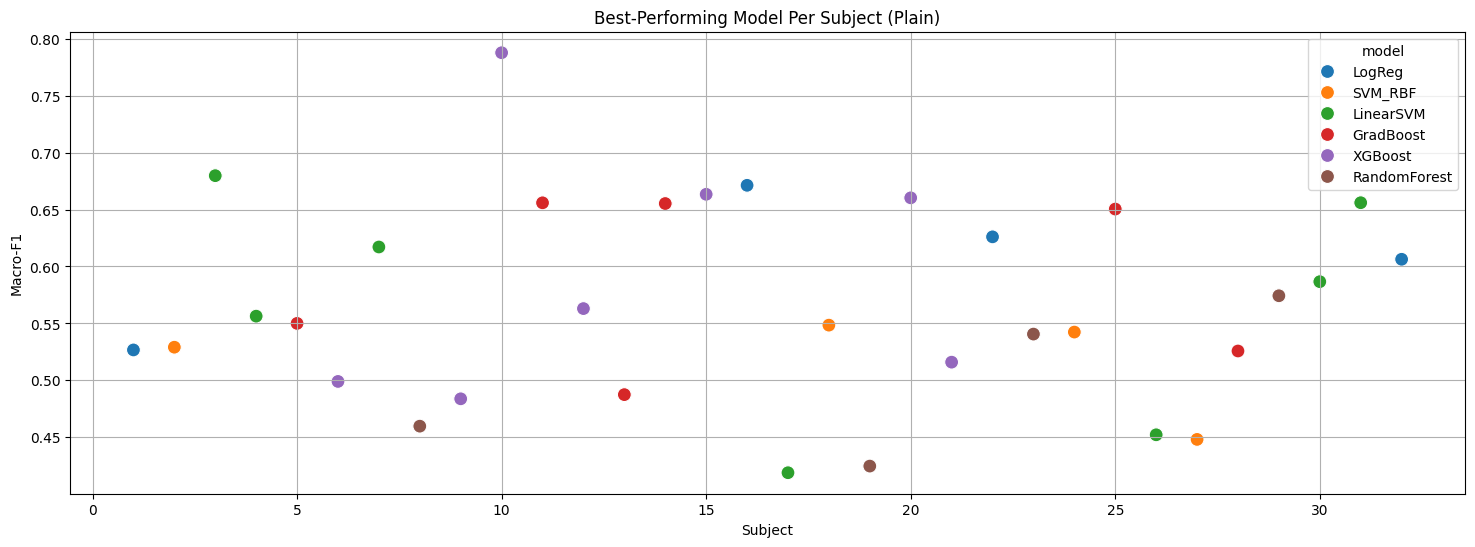

In [ ]:
df_best = (
    df[df["type"] == "Plain"]
    .sort_values(["subject", "f1"], ascending=False)
    .groupby("subject")
    .head(1)
)

df_best["subj_num"] = df_best["subject"].str.replace("s","").astype(int)
df_best = df_best.sort_values("subj_num")

plt.figure(figsize=(18,6))
sns.scatterplot(
    data=df_best,
    x="subj_num",
    y="f1",
    hue="model",
    s=100
)
plt.title("Best-Performing Model Per Subject (Plain)")
plt.xlabel("Subject")
plt.ylabel("Macro-F1")
plt.grid(True)
plt.show()


In [ ]:
d = np.load(FEATURES / "s15_X7_60s_256Hz_final.npz", allow_pickle=True)
X = d["X"].reshape(40, -1).astype(np.float32)
y = d["y"].astype(int)


Original class distribution:
{np.int64(0): np.int64(24), np.int64(1): np.int64(16)}

After SMOTE class distribution:
{np.int64(0): np.int64(24), np.int64(1): np.int64(24)}

Real minority samples:     16
Minority after SMOTE:      24
(Approx) synthetic count:  8

=== SMOTE QUALITY METRICS (MINORITY CLASS) ===
Mean pairwise distance (real minority):           44.2124
Mean distance (SMOTE minority → real minority):   44.5457
Mean feature variance (real minority):            4.9673e+00
Mean feature variance (SMOTE minority):           4.9442e+00
Centroid shift (L2, SMOTE vs real minority):      6.6759

Running PCA for visualization...


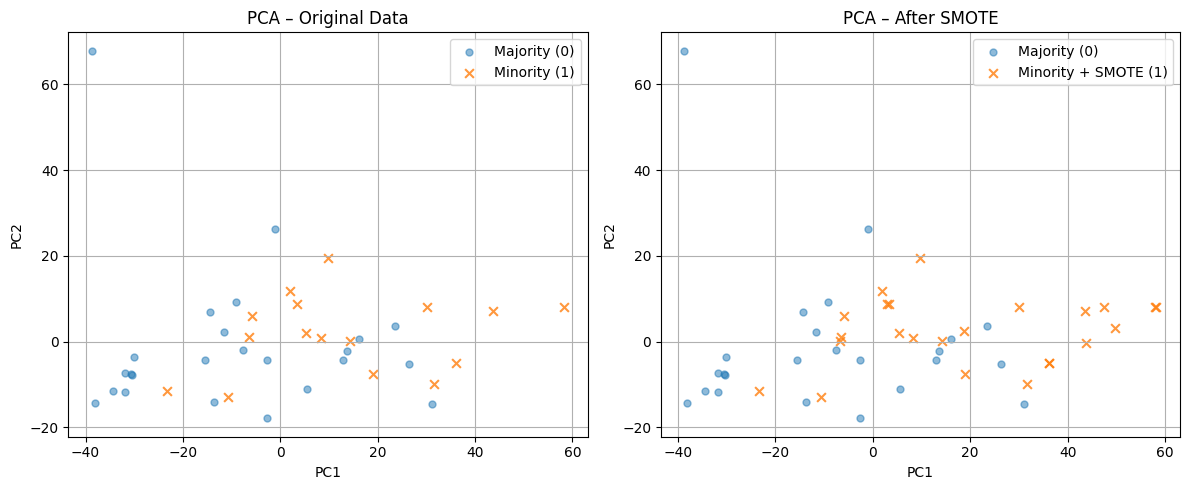

Running t-SNE on SMOTE data (this can take some time)...


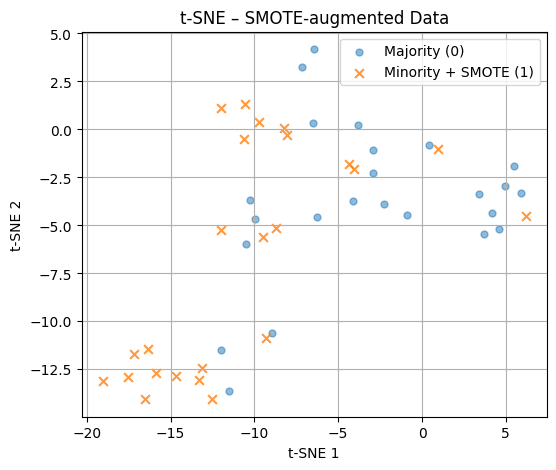


Interpretation for your professor:
- If SMOTE distances and variances are similar to real minority → synthetic samples stay in a realistic region.
- If centroid shift is small → minority distribution is preserved.
- In PCA/t-SNE plots, minority+SMOTE should cluster near original minority, not scattered randomly into majority space.


In [ ]:
##SMOTE Quality

import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# ---------- 1. Run SMOTE ----------
print("Original class distribution:")
unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print("\nAfter SMOTE class distribution:")
unique_res, counts_res = np.unique(y_res, return_counts=True)
print(dict(zip(unique_res, counts_res)))

# ---------- 2. Identify minority data ----------
minority_label = 1  # adjust if your positive class is 0
X_min_real = X[y == minority_label]
X_min_smote_all = X_res[y_res == minority_label]

n_min_real = X_min_real.shape[0]
n_min_after = X_min_smote_all.shape[0]
n_min_synth = n_min_after - n_min_real

print(f"\nReal minority samples:     {n_min_real}")
print(f"Minority after SMOTE:      {n_min_after}")
print(f"(Approx) synthetic count:  {n_min_synth}")

# ---------- 3. Distance / variance / centroid checks ----------

# Mean pairwise distance among real minority
if X_min_real.shape[0] >= 2:
    dist_real = pairwise_distances(X_min_real).mean()
else:
    dist_real = np.nan

# Mean distance: SMOTE minority (all) to real minority
if X_min_real.shape[0] >= 1 and X_min_smote_all.shape[0] >= 1:
    dist_synth = pairwise_distances(X_min_smote_all, X_min_real).mean()
else:
    dist_synth = np.nan

# Variance (mean over features)
var_real = X_min_real.var(axis=0).mean() if X_min_real.shape[0] > 0 else np.nan
var_smote = X_min_smote_all.var(axis=0).mean() if X_min_smote_all.shape[0] > 0 else np.nan

# Centroid shift (L2 distance)
if X_min_real.shape[0] > 0 and X_min_smote_all.shape[0] > 0:
    centroid_real = X_min_real.mean(axis=0)
    centroid_smote = X_min_smote_all.mean(axis=0)
    centroid_shift = np.linalg.norm(centroid_smote - centroid_real)
else:
    centroid_shift = np.nan

print("\n=== SMOTE QUALITY METRICS (MINORITY CLASS) ===")
print(f"Mean pairwise distance (real minority):           {dist_real:.4f}")
print(f"Mean distance (SMOTE minority → real minority):   {dist_synth:.4f}")
print(f"Mean feature variance (real minority):            {var_real:.4e}")
print(f"Mean feature variance (SMOTE minority):           {var_smote:.4e}")
print(f"Centroid shift (L2, SMOTE vs real minority):      {centroid_shift:.4f}")

# ---------- 4. PCA visualization: Plain vs SMOTE ----------
print("\nRunning PCA for visualization...")

pca = PCA(n_components=2, random_state=42)
X_plain_pca = pca.fit_transform(X)
X_smote_pca = pca.transform(X_res)  # same PCA mapping

plt.figure(figsize=(12,5))

# Left: original data
plt.subplot(1, 2, 1)
plt.scatter(
    X_plain_pca[y == 0, 0], X_plain_pca[y == 0, 1],
    alpha=0.5, label="Majority (0)", s=25
)
plt.scatter(
    X_plain_pca[y == 1, 0], X_plain_pca[y == 1, 1],
    alpha=0.8, label="Minority (1)", marker="x", s=40
)
plt.title("PCA – Original Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)

# Right: after SMOTE
plt.subplot(1, 2, 2)
plt.scatter(
    X_smote_pca[y_res == 0, 0], X_smote_pca[y_res == 0, 1],
    alpha=0.5, label="Majority (0)", s=25
)
plt.scatter(
    X_smote_pca[y_res == 1, 0], X_smote_pca[y_res == 1, 1],
    alpha=0.8, label="Minority + SMOTE (1)", marker="x", s=40
)
plt.title("PCA – After SMOTE")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ---------- 5. t-SNE visualization on SMOTE data ----------
print("Running t-SNE on SMOTE data (this can take some time)...")

tsne = TSNE(n_components=2, perplexity=10, random_state=42, init="random", learning_rate="auto")
X_tsne = tsne.fit_transform(X_res)

plt.figure(figsize=(6,5))
plt.scatter(
    X_tsne[y_res == 0, 0], X_tsne[y_res == 0, 1],
    alpha=0.5, label="Majority (0)", s=25
)
plt.scatter(
    X_tsne[y_res == 1, 0], X_tsne[y_res == 1, 1],
    alpha=0.8, label="Minority + SMOTE (1)", marker="x", s=40
)
plt.title("t-SNE – SMOTE-augmented Data")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.grid(True)
plt.show()

print("\nInterpretation for your professor:")
print("- If SMOTE distances and variances are similar to real minority → synthetic samples stay in a realistic region.")
print("- If centroid shift is small → minority distribution is preserved.")
print("- In PCA/t-SNE plots, minority+SMOTE should cluster near original minority, not scattered randomly into majority space.")


In [ ]:
import json
import pandas as pd
import numpy as np
from pathlib import Path

ROOT = "/content/drive/MyDrive/Dissertation/Dataset"
METRICS_PATH = Path(ROOT) / "data" / "metrics" / "subject_metrics.json"

store = json.load(open(METRICS_PATH, "r"))

models_order = ["LogReg","LinearSVM","SVM_RBF","RandomForest","GradBoost","XGBoost"]

rows = []
for subj, blob in store.items():
    for setting in ["plain","smote"]:
        models = blob[setting]["models"]
        for m in models_order:
            if m in models:
                rows.append({
                    "subject": subj,
                    "setting": setting,
                    "model": m,
                    "acc_mean": models[m]["acc_mean"],
                    "acc_std": models[m]["acc_std"],
                    "f1_mean": models[m]["f1_mean"],
                    "f1_std": models[m]["f1_std"],
                })

df = pd.DataFrame(rows)

# Table 4.1 / 4.2: aggregate across subjects (mean±SD across subjects)
agg = (df.groupby(["setting","model"])
         .agg(acc_mean_mean=("acc_mean","mean"),
              acc_mean_sd=("acc_mean","std"),
              f1_mean_mean=("f1_mean","mean"),
              f1_mean_sd=("f1_mean","std"))
         .reset_index())

# Table 4.5: delta macro-F1 per subject then aggregate across subjects
plain = df[df.setting=="plain"][["subject","model","f1_mean"]].rename(columns={"f1_mean":"f1_plain"})
smote = df[df.setting=="smote"][["subject","model","f1_mean"]].rename(columns={"f1_mean":"f1_smote"})
delta = plain.merge(smote, on=["subject","model"], how="inner")
delta["delta_f1"] = delta["f1_smote"] - delta["f1_plain"]

delta_agg = (delta.groupby("model")
                  .agg(delta_mean=("delta_f1","mean"),
                       delta_sd=("delta_f1","std"))
                  .reset_index())

# print in your preferred order
agg["model"] = pd.Categorical(agg["model"], categories=models_order, ordered=True)
agg = agg.sort_values(["setting","model"])

delta_agg["model"] = pd.Categorical(delta_agg["model"], categories=models_order, ordered=True)
delta_agg = delta_agg.sort_values("model")

print("\n=== TABLE 4.1 (PLAIN): mean±SD across subjects ===")
print(agg[agg.setting=="plain"][["model","acc_mean_mean","acc_mean_sd","f1_mean_mean","f1_mean_sd"]].round(3))

print("\n=== TABLE 4.2 (SMOTE): mean±SD across subjects ===")
print(agg[agg.setting=="smote"][["model","acc_mean_mean","acc_mean_sd","f1_mean_mean","f1_mean_sd"]].round(3))

print("\n=== TABLE 4.5 (Δ macro-F1 = SMOTE - Plain): mean±SD across subjects ===")
print(delta_agg[["model","delta_mean","delta_sd"]].round(3))



=== TABLE 4.1 (PLAIN): mean±SD across subjects ===
          model  acc_mean_mean  acc_mean_sd  f1_mean_mean  f1_mean_sd
2        LogReg          0.519        0.130         0.472       0.115
1     LinearSVM          0.521        0.113         0.484       0.112
4       SVM_RBF          0.534        0.126         0.466       0.100
3  RandomForest          0.566        0.116         0.466       0.080
0     GradBoost          0.538        0.111         0.493       0.091
5       XGBoost          0.535        0.117         0.466       0.111

=== TABLE 4.2 (SMOTE): mean±SD across subjects ===
           model  acc_mean_mean  acc_mean_sd  f1_mean_mean  f1_mean_sd
8         LogReg          0.519        0.128         0.472       0.114
7      LinearSVM          0.534        0.116         0.480       0.101
10       SVM_RBF          0.538        0.135         0.445       0.108
9   RandomForest          0.547        0.127         0.474       0.110
6      GradBoost          0.519        0.101       

In [ ]:
!pip install mne
# ==============================
# Table A.1 helper: events + epochs retention + drop reasons
# ==============================
import numpy as np
import pandas as pd
from pathlib import Path

ROOT = "/content/drive/MyDrive/Dissertation/Dataset"
INTERIM  = Path(ROOT) / "data" / "interim"
FEATURES = Path(ROOT) / "data" / "features"

SUBJECTS = [f"s{i:02d}" for i in range(1, 33)]

def _summarise_drop_log(drop_log, top_k=3):
    """
    drop_log: epochs.drop_log (list of tuples/strings)
    returns: short human-readable summary of common reasons
    """
    reasons = []
    for entry in drop_log:
        if entry is None:
            continue
        # entry can be: (), ('EOG',), ('BAD_artifact',), ('Fp1', 'Fp2'), 'IGNORED', etc.
        if isinstance(entry, (tuple, list)):
            if len(entry) == 0:
                continue
            reasons.extend([str(x) for x in entry if str(x).strip()])
        else:
            s = str(entry).strip()
            if s and s != "()":
                reasons.append(s)

    if not reasons:
        return "None / no drops"

    # count and keep top reasons
    vc = pd.Series(reasons).value_counts()
    top = vc.head(top_k)
    # compress: "Fp1 (7), Fp2 (5), EOG (3)"
    return ", ".join([f"{idx} ({cnt})" for idx, cnt in top.items()])

def collect_table_A1_from_epochs_loader(load_subject_epochs_fn, subjects=SUBJECTS):
    """
    You must provide: load_subject_epochs_fn(subj) -> (raw_events_count, epochs_obj)
    - raw_events_count: int (events detected BEFORE epoch rejection)
    - epochs_obj: mne.Epochs (after rejection) with .drop_log present

    Returns DataFrame for Table A.1.
    """
    rows = []
    for subj in subjects:
        try:
            n_events, epochs = load_subject_epochs_fn(subj)
            n_epochs = len(epochs)
            drop_summary = _summarise_drop_log(getattr(epochs, "drop_log", None))
            rows.append({
                "Subject": subj,
                "EventsDetected": int(n_events),
                "EpochsRetained": int(n_epochs),
                "CommonDropReasons": drop_summary
            })
        except Exception as e:
            rows.append({
                "Subject": subj,
                "EventsDetected": np.nan,
                "EpochsRetained": np.nan,
                "CommonDropReasons": f"FAILED: {type(e).__name__}: {e}"
            })

    df = pd.DataFrame(rows)
    return df

# ==============================
# OPTION 1 (Recommended): Use your saved preprocessed epochs FIF files
# You must edit these paths/filenames to match your notebook outputs.
# ==============================
import mne

def load_subject_epochs_from_fif(subj):
    """
    EDIT THIS to match YOUR saved epochs filename pattern.
    You need two things:
    (1) n_events detected BEFORE rejection -> store it in metadata or re-run event extraction
    (2) epochs after rejection -> epochs object
    """
    # --- Example filename patterns (change to your real ones) ---
    # epochs_path = INTERIM / subj / f"{subj}_epochs_clean-epo.fif"
    # or: epochs_path = INTERIM / f"{subj}_clean-epo.fif"
    epochs_path = INTERIM / subj / f"{subj}_epochs_clean-epo.fif"  # <-- CHANGE THIS

    epochs = mne.read_epochs(epochs_path, preload=False, verbose="ERROR")

    # If you did not store "events detected before rejection", best proxy is epochs.events length + dropped count.
    # Better: re-run event detection from raw, but that requires your raw loading code.
    # Here we approximate as total epochs attempted = len(drop_log), if drop_log is present.
    if hasattr(epochs, "drop_log") and epochs.drop_log is not None:
        n_events_detected = len(epochs.drop_log)  # epochs created before dropping
    else:
        n_events_detected = len(epochs.events)

    return n_events_detected, epochs

# Example run (will fail until you fix epochs_path pattern):
# df_A1 = collect_table_A1_from_epochs_loader(load_subject_epochs_from_fif)
# display(df_A1)

# ==============================
# OPTION 2: If you ONLY have final NPZ features (no epochs saved),
# you can still fill EventsDetected=40 (expected) and EpochsRetained = n_trials in NPZ.
# Drop reasons will be "Not available (epochs not stored)".
# ==============================
def collect_table_A1_from_npz(subjects=SUBJECTS, npz_suffix="_X7_60s_256Hz_final.npz"):
    rows = []
    for subj in subjects:
        npz_path = FEATURES / f"{subj}{npz_suffix}"
        if not npz_path.exists():
            rows.append({
                "Subject": subj,
                "EventsDetected": np.nan,
                "EpochsRetained": np.nan,
                "CommonDropReasons": "MISSING NPZ"
            })
            continue
        fx = np.load(npz_path, allow_pickle=True)
        n_epochs = int(fx["X"].shape[0])

        rows.append({
            "Subject": subj,
            "EventsDetected": 40,  # expected trials; replace if you can compute true detected events
            "EpochsRetained": n_epochs,
            "CommonDropReasons": "Not available (epochs/drop_log not stored)"
        })
    return pd.DataFrame(rows)

# If you don't have saved epochs, run this now:
# df_A1_npz = collect_table_A1_from_npz()
# display(df_A1_npz)

# ==============================
# SAVE to CSV so you can share results quickly
# ==============================
def save_table(df, out_path):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_path, index=False)
    print("Saved:", out_path)

# Example:
# save_table(df_A1_npz, Path(ROOT)/"data"/"metrics"/"table_A1_epochs_retention.csv")


In [ ]:
df_A1 = collect_table_A1_from_npz()
display(df_A1)
save_table(df_A1, Path(ROOT)/"data"/"metrics"/"table_A1_epochs_retention.csv")
